In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import os
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import time
import json
import dask.dataframe as dd
from dask.distributed import Client

client = Client(n_workers=4, threads_per_worker=2) 

In [ ]:
base_dir = os.getcwd() 

data_dir = os.path.join(base_dir, 'data', 'telecom')
grid_file = os.path.join(base_dir, 'data', 'milano-grid.geojson')

## Task 1

In [3]:
# load the data (lazy loading with Dask)
df = dd.read_csv(
    data_dir + '/*.txt',
    sep='\t', 
    header=None,
    usecols=[0,1,7],
    names=['square_id', 'timestamp', 'activity'], 
    dtype={'square_id': 'int32', 'activity': 'float32'})

# load the grid file 
grid = gpd.read_file(grid_file)

In [4]:
# compute the total internet CDR per square
traffic_per_square = df.groupby('square_id')['activity'].sum().compute()

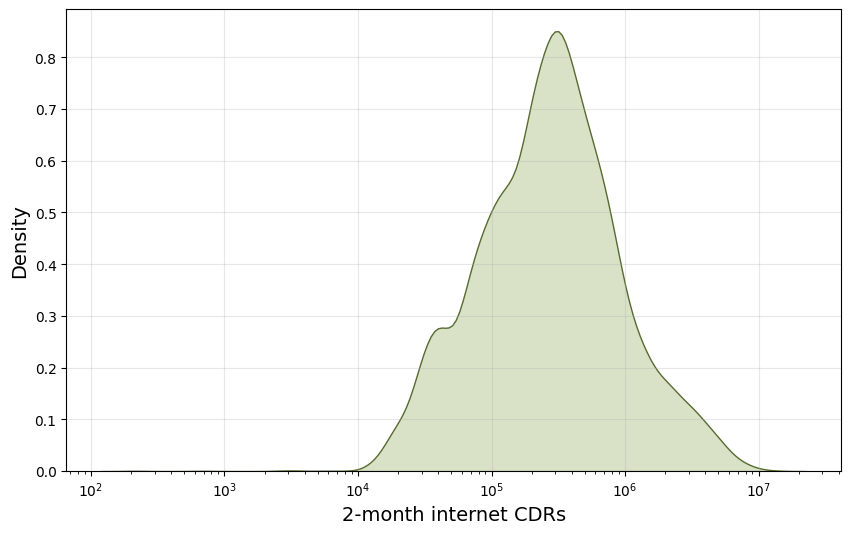

In [5]:
# plot the PDF of the traffic computed over 2 months
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=traffic_per_square, 
    fill=True, 
    log_scale=True, 
    color="olivedrab", 
    edgecolor="darkolivegreen"
)
#plt.title('PDF of 2-month internet CDR', fontsize=18)
plt.xlabel('2-month internet CDRs', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('traffic_pdf.png', dpi=300)
plt.show()

In [6]:
# convert timestamp to datetime
df['timestamp'] = dd.to_datetime(df['timestamp'], unit='ms')

# select a representative subset of areas for training and validation of the model in task 2 
sorted_areas = traffic_per_square.sort_values(ascending=False).index.tolist()
areas = set(sorted_areas[:25] + sorted_areas[4975:5000] + sorted_areas[-25:] + [4159, 4556]) 

In [ ]:
# if we already have the training dataset, load it, otherwise create it from scratch and save it
if os.path.exists('data/df.parquet'):
    print(f"Loading filtered dataset.")
    train_df = pd.read_parquet('df.parquet', engine='pyarrow')

else:
    print("File not found, creating the dataset from scratch.")
    train_df = (
        df[df['square_id'].isin(areas)]
        .compute()
        .groupby(['square_id', 'timestamp'])['activity']
        .sum() # sum multiple records for the same square and timestamp
        .reset_index()
    )
    train_df.to_parquet(
        'data/df.parquet', 
        engine='pyarrow', 
        compression='snappy'
    )

Loading filtered dataset.


In [8]:
# work on the three required areas, isolating the first two weeks of data
filtered_areas = [sorted_areas[0], 4159, 4556]

t_start = train_df['timestamp'].min()
t_end = t_start + pd.Timedelta(weeks=2)

df_two_weeks = train_df[
    train_df['square_id'].isin(filtered_areas) & 
    (train_df['timestamp'] < t_end)
    ].copy()

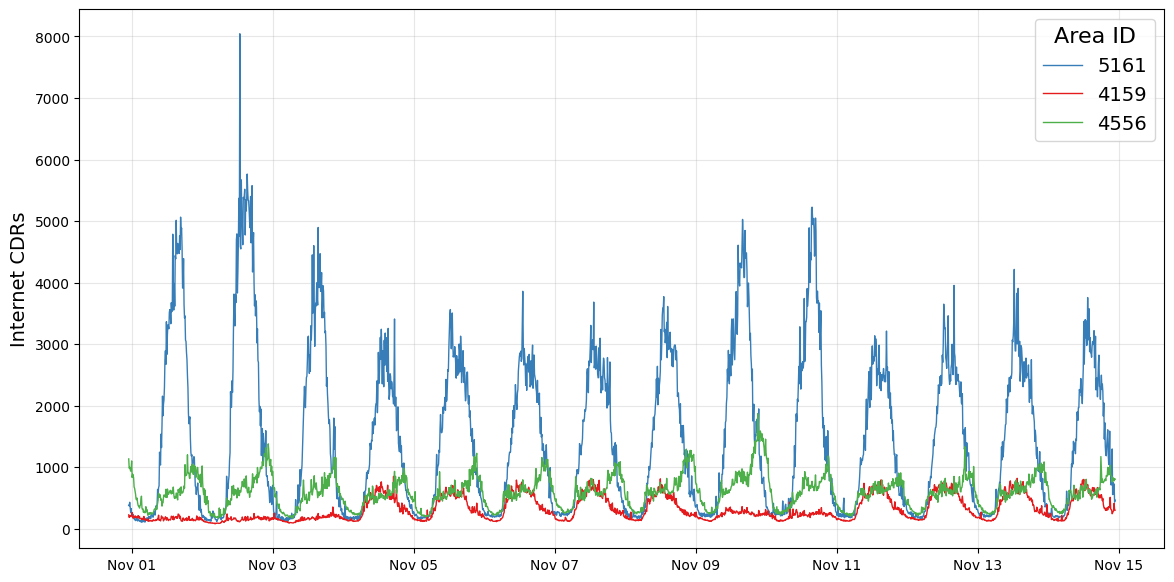

In [9]:
import matplotlib.dates
color_palette = ['#377eb8', '#e41a1c', '#4daf4a']

labels = {sorted_areas[0]:f'{sorted_areas[0]}', 4159: '4159', 4556: '4556'}
df_two_weeks['area'] = df_two_weeks['square_id'].map(labels)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_two_weeks,
    x='timestamp',
    y='activity',
    hue='area',
    hue_order=[f'{sorted_areas[0]}', '4159', '4556'],
    palette=color_palette,
    linewidth=1
)

plt.ylabel('Internet CDRs', fontsize=14)
plt.xlabel('')

plt.legend(
    title='Area ID', 
    title_fontsize=16, 
    fontsize=14,       
    loc='upper right',  
    frameon=True      
)

plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%b %d'))
plt.grid(True, alpha=0.3)
plt.savefig('time_series.png', dpi=300, bbox_inches='tight')
plt.show()

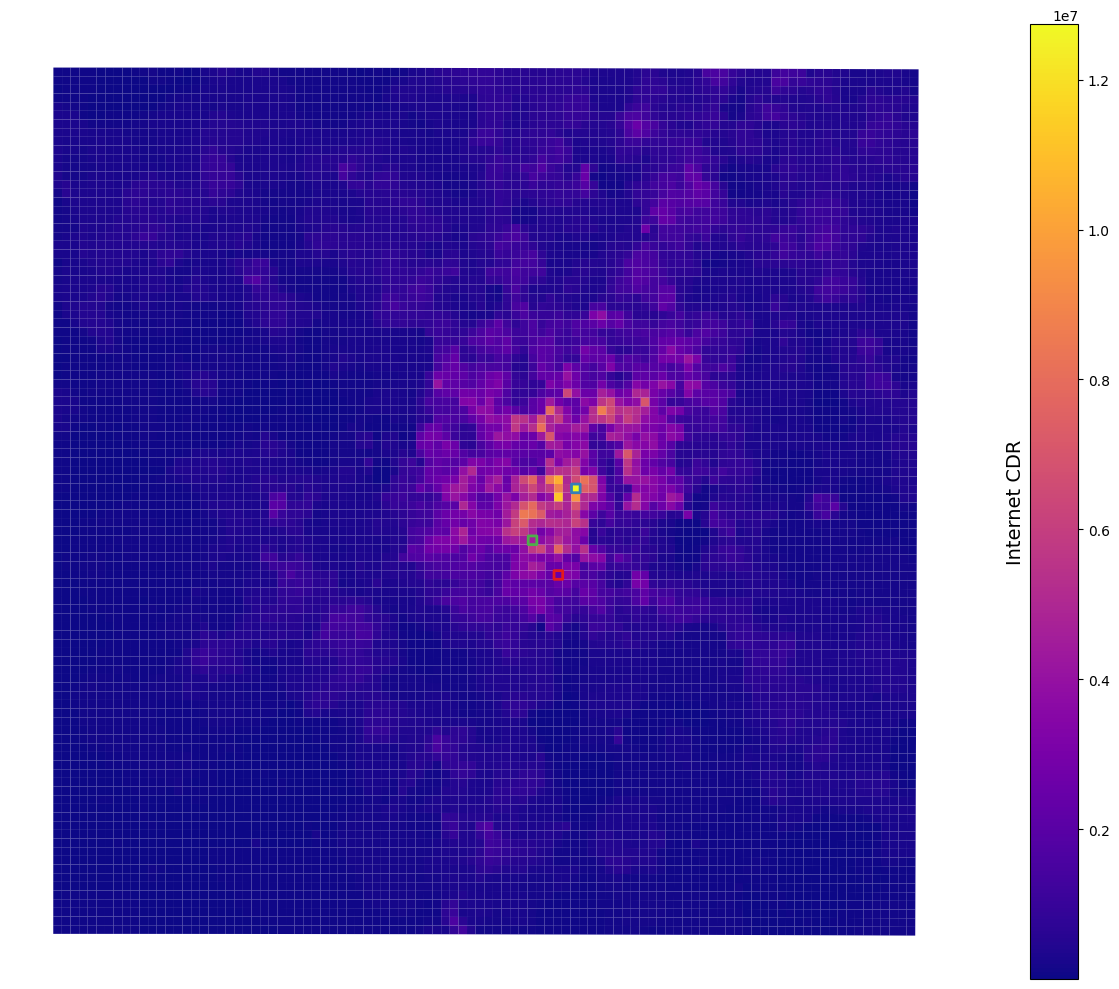

In [10]:
# merge the traffic data with the grid to visialize the spatial distribution of traffic
grid_traffic = grid.merge(
    traffic_per_square.rename('total_activity'),
    left_on='cellId',
    right_index=True,
    how='left'
)

area_colors = dict(zip(filtered_areas, color_palette))

fig, ax = plt.subplots(figsize=(14, 10))
grid_traffic.plot(
    column='total_activity',
    cmap='plasma',
    legend=True,
    legend_kwds={'label': 'Total CDR'},
    ax=ax,
)
cax = fig.get_axes()[-1] 
cax.yaxis.set_label_position('left')
cax.set_ylabel('Internet CDR', fontsize=14)

for area_id, color in area_colors.items():
    grid_traffic[grid_traffic['cellId'] == area_id].plot(
        ax=ax,
        edgecolor=color, 
        facecolor='none',
        linewidth=2
    )
#ax.set_title('Spatial Distribution of Internet CDR in Milan', fontsize=18)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('spatial_distribution.png', dpi=300)
plt.show()

In [ ]:
# coordinates to identify the target areas 
for area in filtered_areas:
    centroid = (
        grid[grid['cellId'] == area]
        .to_crs(epsg=3035) 
        .geometry.centroid
        .to_crs(epsg=4326) 
        .iloc[0]
    )
    print(f"Coordinates for area {area}: {centroid.y}, {centroid.x}")

Coordinates for area 5161: 45.46546082347206, 9.193381345732588
Coordinates for area 4159: 45.44431812014326, 9.187299156002277
Coordinates for area 4556: 45.45279364933755, 9.178310947437783


-------
## Task 2

In [12]:
# feature engineering function to create lag and rolling features for the time series forecasting model
def make_features(df):
    df = df.copy()

    # datetime features
    df['hour'] = df['timestamp'].dt.hour
    df['day'] = df['timestamp'].dt.dayofweek
    
    # lag features
    df['lag_1'] = df['activity'].shift(1) # traffic 10 mins ago 
    df['lag_6'] = df['activity'].shift(6) # traffic 1 hour ago
    df['lag_144'] = df['activity'].shift(144) # traffic 1 day ago
    df['lag_1008'] = df['activity'].shift(1008) # traffic 1 week ago

    # rolling features
    df['hour_mean'] = df['activity'].shift(1).rolling(6).mean() # mean traffic in the last hour
    df['day_mean'] = df['activity'].shift(1).rolling(144).mean() # mean traffic in the last day
    
    return df.dropna()

In [13]:
train_df = (
    train_df
    .groupby('square_id', group_keys=False)[['square_id', 'timestamp', 'activity']]
    .apply(make_features)
)

val_start  = pd.Timestamp('2013-12-09')
test_start  = pd.Timestamp('2013-12-16')
test_end    = pd.Timestamp('2013-12-23 00:00:00')

train = train_df[train_df['timestamp'] < val_start]
val   = train_df[(train_df['timestamp'] >= val_start) & 
                 (train_df['timestamp'] < test_start)]
test  = train_df[(train_df['timestamp'] >= test_start) & 
                 (train_df['timestamp'] < test_end)]

FEATURES = ['hour', 'day', 'lag_1', 'lag_6', 'lag_144', 'lag_1008', 'hour_mean', 'day_mean', 'square_id']

X_train, y_train = train[FEATURES], train['activity']
X_val,   y_val   = val[FEATURES],   val['activity']
X_test,  y_test  = test[FEATURES],  test['activity']

In [ ]:
if os.path.exists('model/best_model.json'):
    print(f"Loading best model ...")
    
    model = xgb.XGBRegressor()
    model.load_model('model/best_model.json')

    with open('model/best_params.json', 'r') as f:
        best_params = json.load(f)
    
else:
    print("File not found, training model and performing hyperparameter tuning ...\n")

    best_mae = float('inf')

    for lr in [0.01, 0.05, 0.1]:
        for depth in [4, 6, 8]:
            for n in [300, 500, 1000]:

                model = xgb.XGBRegressor(
                    n_estimators=n,
                    learning_rate=lr,
                    max_depth=depth,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    early_stopping_rounds=50,
                    random_state=42, 
                    n_jobs=-1,
                    tree_method='hist',
                    eval_metric='mae', 
                    objective='reg:squarederror'
                    )
                model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

                val_mae = mean_absolute_error(y_val, model.predict(X_val))
                print(f"lr={lr}, depth={depth}, n_estimators={n} → MAE={val_mae:.4f}")

                if val_mae < best_mae:
                    best_mae = val_mae
                    best_params = {
                        'learning_rate': lr,
                        'max_depth': depth,
                        'n_estimators': n,
                        'mae': float(val_mae)
                    }
                    model.save_model('model/best_model.json')
                    
                    with open('model/best_params.json', 'w') as f:
                        json.dump(best_params, f)

print(f"\nBest params: lr={best_params['learning_rate']}, depth={best_params['max_depth']}, n={best_params['n_estimators']}")
print(f"Best val MAE: {best_params['mae']:.4f}")

Loading best model ...

Best params: lr=0.01, depth=8, n=1000
Best val MAE: 22.7555


In [15]:
# measure training time 
t0 = time.perf_counter()
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
t_train = time.perf_counter() - t0

# obtain statistics on inference time 
infer_times = []
for _ in range(5):
    t0 = time.perf_counter()
    y_pred = model.predict(X_val)
    infer_times.append(time.perf_counter() - t0)

print(f"Training time: {t_train:.4f} seconds")
print(f"Inference time: {np.mean(infer_times):.4f} seconds ± {np.std(infer_times):.4f} seconds")

Training time: 18.8338 seconds
Inference time: 0.0889 seconds ± 0.0103 seconds


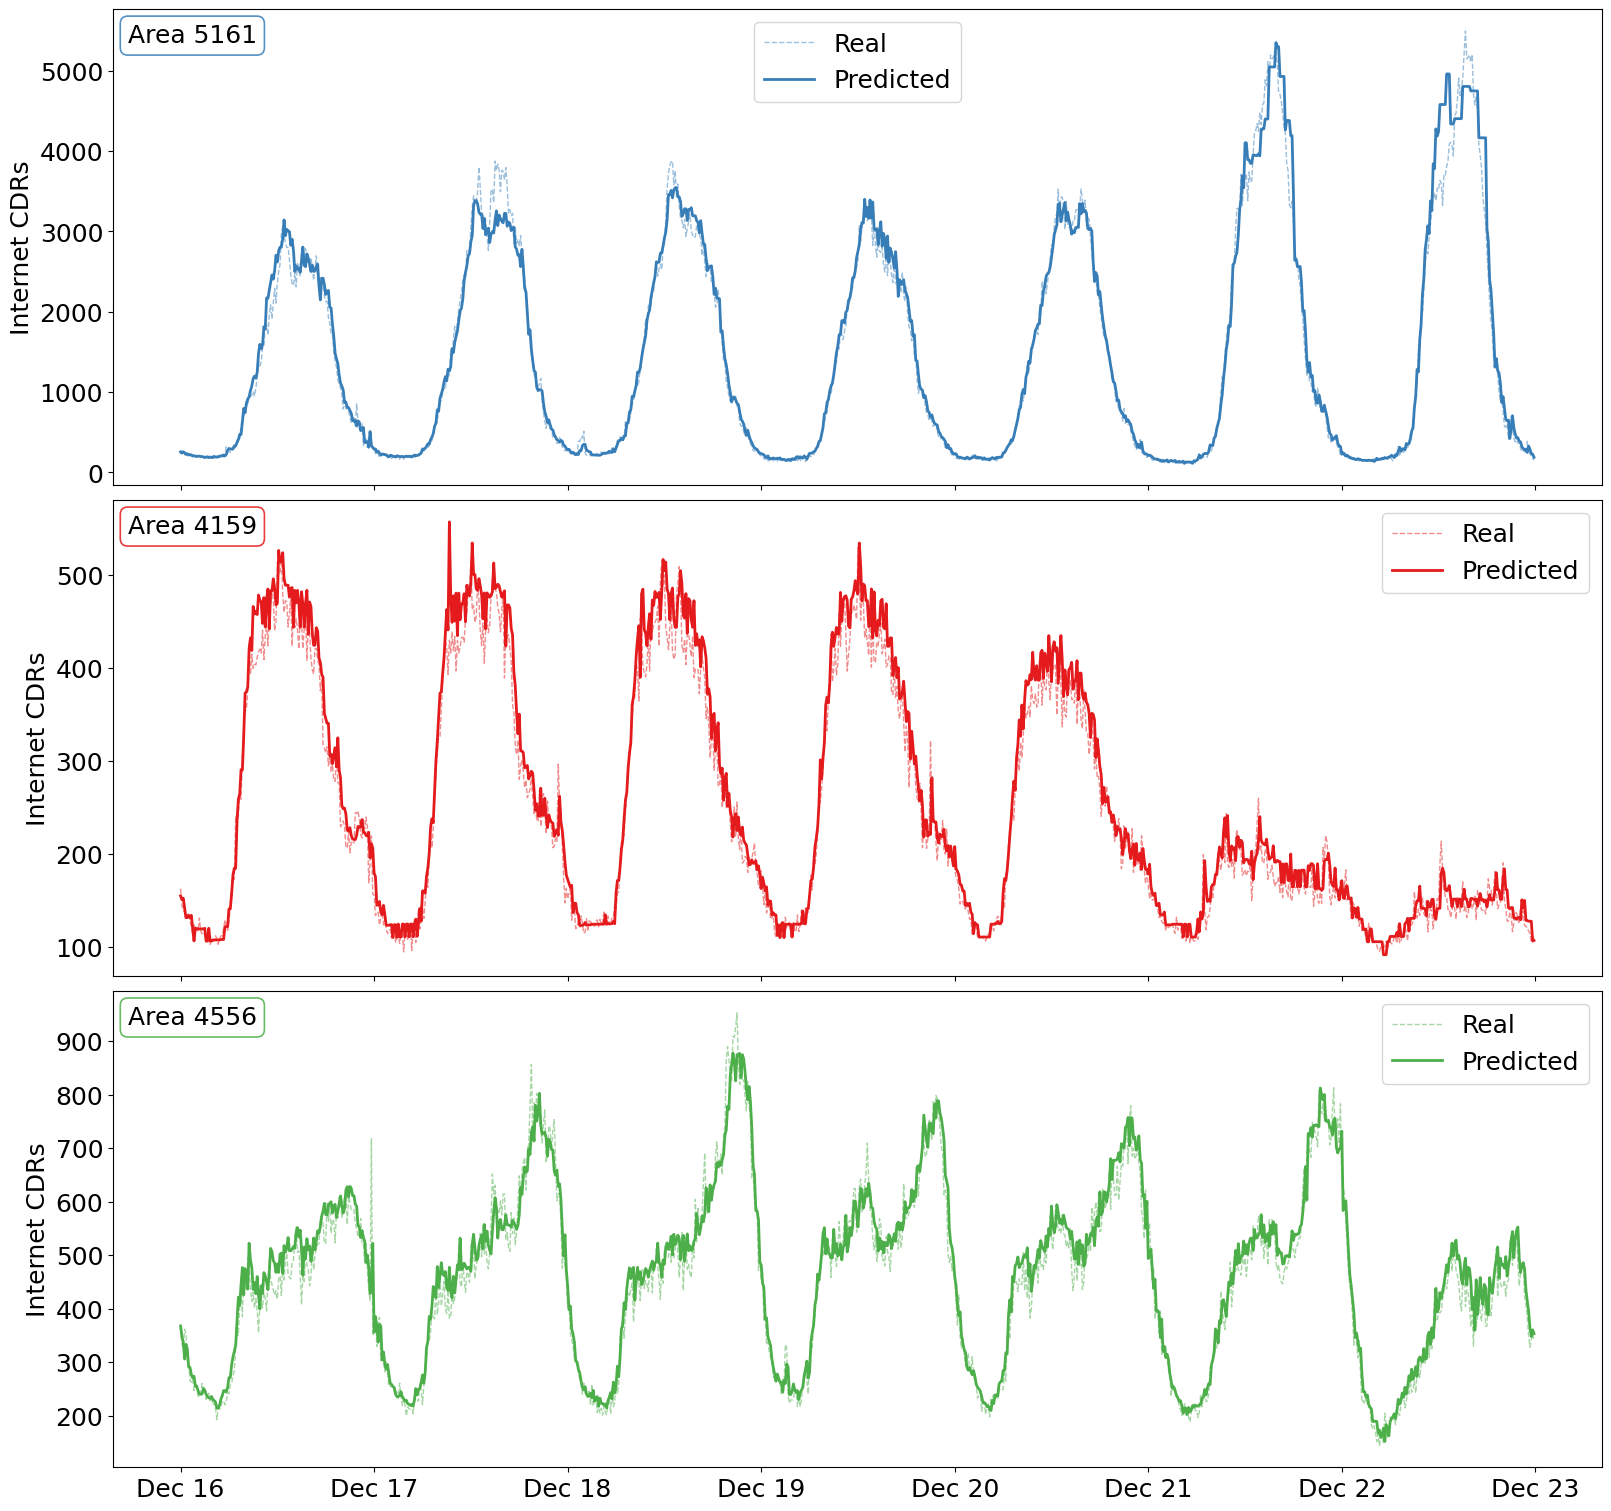

In [16]:
areas = [5161, 4159, 4556]
color_palette = ['#377eb8', '#e41a1c', '#4daf4a']

fig, axes = plt.subplots(3, 1, figsize=(16, 15), constrained_layout=True)
#fig.suptitle('Predicted vs Real (Dec 16–22)', fontsize=20)

errors = {}
for ax, area, color in zip(axes, areas, color_palette):

    mask = X_test['square_id'] == area
    y_pred = model.predict(X_test[mask])
    y_true = y_test[mask]
    timestamps = test[mask]['timestamp']

    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    errors[area] = {'mae': mae, 'mape': mape}

    ax.plot(timestamps, y_true.values,
            label='Real',
            color=color, alpha=0.5,
            linewidth=1, linestyle='--')

    ax.plot(timestamps, y_pred,
            label='Predicted',
            color=color,
            linewidth=2, linestyle='-')

    # box area in alto a sinistra
    ax.text(0.01, 0.97, f'Area {area}',
            transform=ax.transAxes,
            fontsize=18, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white',
                      edgecolor=color,
                      linewidth=1.2,
                      alpha=0.85))

    ax.set_ylabel('Internet CDRs', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)
    ax.legend(title_fontsize=18, fontsize=18, framealpha=0.8)

    ax.xaxis.set_major_formatter(
        plt.matplotlib.dates.DateFormatter('%b %d'))
    fig.autofmt_xdate(rotation=0, ha='center')

plt.savefig('predictions.png', dpi=500, bbox_inches='tight')
plt.show()

In [17]:
print(f"{'Area':<10} {'MAE':>10} {'MAPE':>10}")
print('-' * 32)
for area, metrics in errors.items():
    print(f"{area:<10} {metrics['mae']:>10.1f} {metrics['mape']:>10.1%}")

Area              MAE       MAPE
--------------------------------
5161            120.6      10.0%
4159             18.7       7.9%
4556             29.1       6.7%
